# MC 구현: 3x4 그리드 월드 예제

### GridWorld 시각화를 위한 설정

In [5]:
import os
import urllib.request

if not os.path.exists("gridworld_render.py"):
    url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/main/common/gridworld_render.py"
    filename = "gridworld_render.py"
    urllib.request.urlretrieve(url, filename)

In [6]:
import numpy as np
import gridworld_render as render_helper
from collections import defaultdict

### GridWorld 클래스의 정의

In [7]:
class GridWorld:
    def __init__(self):
        self.action_space = [0, 1, 2, 3]  # 행동 공간(가능한 행동들)
        self.action_meaning = {  # 행동의 의미
            0: "UP",
            1: "DOWN",
            2: "LEFT",
            3: "RIGHT",
        }

        self.reward_map = np.array(  # 보상 맵(각 좌표의 보상 값)
            [[0, 0, 0, 1.0],
             [0, None, 0, -1.0],
             [0, 0, 0, 0]]
        )
        self.goal_state = (0, 3)    # 목표 상태(좌표)
        self.wall_state = (1, 1)    # 벽 상태(좌표)
        self.start_state = (2, 0)   # 시작 상태(좌표)
        self.agent_state = self.start_state   # 에이전트 초기 상태(좌표)

    @property
    def height(self):
        return len(self.reward_map)

    @property
    def width(self):
        return len(self.reward_map[0])

    @property
    def shape(self):
        return self.reward_map.shape

    def actions(self):
        return self.action_space

    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h, w)

    def next_state(self, state, action):
        # 이동 위치 계산
        action_move_map = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        move = action_move_map[action]
        next_state = (state[0] + move[0], state[1] + move[1])
        ny, nx = next_state

        # 이동한 위치가 그리드 월드의 테두리 밖이나 벽인가?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state  # 다음 상태 반환

    def reward(self, state, action, next_state):
        return self.reward_map[next_state]

    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state

    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action)
        reward = self.reward(state, action, next_state)
        done = (next_state == self.goal_state)

        self.agent_state = next_state
        return next_state, reward, done

    def render_v(self, v=None, policy=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        renderer = render_helper.Renderer(self.reward_map, self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)


### GridWorld 클래스에서의 step() 메서드 이해: 에이전트에게 행동을 시키는 메서드

In [8]:
env = GridWorld()
action = 0  # 더미 행동
next_state, reward, done = env.step(action) # 행동 수행

print("다음 상태:", next_state)
print("보상:", reward)
print("종료 여부:", done)

다음 상태: (1, 0)
보상: 0
종료 여부: False


### RandomAgent() 클래스 구현

- MC 를 이용하여 정책 평가를 수행하는 에이전트 구현: 무작위 정책에 따라 행동하는 에이전트

In [9]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):  # 역방향으로(reserved) 따라가기
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]


### RandomAgent 클래스와 환경을 구현한 GridWorld 클래스 연동 및 실행

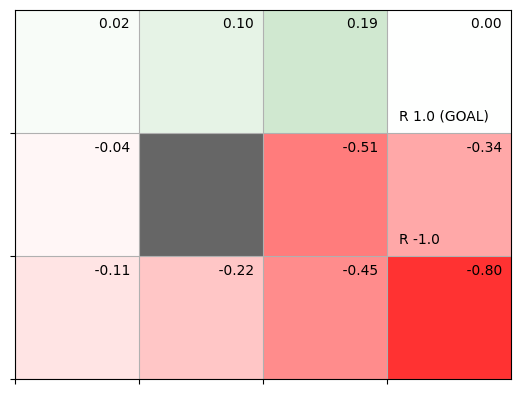

In [ ]:
env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):  # 에피소드 1000번 수행
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)             # 행동 선택
        next_state, reward, done = env.step(action)  # 행동 수행

        agent.add(state, action, reward)  # (상태, 행동, 보상) 저장
        if done:   # 목표에 도달 시
            agent.eval()  # 몬테카를로법으로 가치 함수 갱신
            break         # 다음 에피소드 시작

        state = next_state

# 몬테카를로법으로 얻은 가치 함수 시각화
env.render_v(agent.V)